In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load data (from Day 1)
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# ============================================
# PART 1: SIMPLE LINEAR REGRESSION (1 feature)
# ============================================

# Prepare data
X_simple = df[['MedInc']]  # 1 column
y = df['MedHouseVal']

# Split
X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
# Scale
scaler_simple = StandardScaler()
X_train_s_scaled = scaler_simple.fit_transform(X_train_simple)
X_test_s_scaled = scaler_simple.transform(X_test_simple)

print("Simple Linear Regression:")
print(f"X_train shape: {X_train_simple.shape}")
print(f"X_test shape: {X_test_simple.shape}")
print()

# Simple linear regression
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        n_samples = len(X)

# Initialize w and b to 0
        w = 0
        b = 0

# Make the iterations
        for iteration in range(self.n_iterations):


# Make predictions using current w and b
            y_pred = w * X + b

# Calculate the error
            error = y_pred - y

# Calculate the cost
            cost = (1/(2*n_samples)) * np.sum(error ** 2)

# Calculate the Derivatives
            dw = (1/n_samples) * np.sum(error * X)
            db = (1/n_samples) * np.sum(error)

# Update w and b
            w = w - self.learning_rate * dw
            b = b - self.learning_rate * db

# Print progress after every 10 iteration
            if iteration % 50 == 0:
                print(f"iterations : {iteration:3d}, cost : {cost:.4f}")

        self.w = w
        self.b = b
        return self

    def predict(self, X):
        return np.dot(X, self.w) + self.b

# Train the model
model_simple = LinearRegressionGD(learning_rate=0.01, n_iterations=500)
model_simple.fit(X_train_s_scaled, y_train.values.reshape(-1,1))

# Predict
y_pred_simple = model_simple.predict(X_test_s_scaled)

# Calculate error
simple_mse = np.mean((y_pred_simple.flatten() - y_test) ** 2)
print(f"Simple Model MSE: {simple_mse:.4f}")



Simple Linear Regression:
X_train shape: (16512, 1)
X_test shape: (4128, 1)

iterations :   0, cost : 2.8149
iterations :  50, cost : 1.2520
iterations : 100, cost : 0.6799
iterations : 150, cost : 0.4705
iterations : 200, cost : 0.3938
iterations : 250, cost : 0.3658
iterations : 300, cost : 0.3555
iterations : 350, cost : 0.3517
iterations : 400, cost : 0.3504
iterations : 450, cost : 0.3499
Simple Model MSE: 0.7093


In [37]:
# ============================================
# PART 2: POLYNOMIAL REGRESSION (3 degrees)
# ============================================
from sklearn.preprocessing import StandardScaler

# Step 1: Create polynomial features FIRST
X_poly = np.column_stack([
    df['MedInc'],      # degree 1
    df['MedInc'] ** 2, # degree 2
    df['MedInc'] ** 3  # degree 3
])

# Step 2: Split BEFORE scaling
X_train_poly, X_test_poly, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Step 3: Create scaler
scaler_poly = StandardScaler()

# Step 4: Fit on TRAINING only, then transform
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)


# Polynomial Regression
class PolynomialRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=500):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for iteration in range(self.n_iterations):

# Make predictions using current w and b
            y_pred_poly = np.dot(X, self.weights) + self.bias

# Calculate the cost
            cost_poly = (1/n_samples) * np.sum((y_pred_poly - y)** 2)
            self.cost_history.append(cost_poly)

# Calculate the Derivatives
            dw_poly = (2/n_samples) * np.dot(X.T,(y_pred_poly - y))
            db_poly = (2/n_samples) * np.sum(y_pred_poly - y)

# Update the w and b
            self.weights -= self.learning_rate * dw_poly
            self.bias -= self.learning_rate * db_poly

# make the iterations
            if iteration % 50 == 0:
                print(f"iterations : {iteration:3d}, cost : {cost_poly:.4f}")
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train
model_poly = PolynomialRegressionGD(learning_rate=0.01, n_iterations=500)
model_poly.fit(X_train_poly_scaled, y_train.values.reshape(-1,1))

# Predict
y_pred_poly = model_poly.predict(X_test_poly_scaled)


# Calculate error
poly_mse = np.mean((y_pred_poly.flatten() - y_test) ** 2)
print(f"Polynomial Model MSE: {poly_mse:.4f}")


iterations :   0, cost : 5.6297
iterations :  50, cost : 1.3400
iterations : 100, cost : 0.8180
iterations : 150, cost : 0.7345
iterations : 200, cost : 0.7136
iterations : 250, cost : 0.7042
iterations : 300, cost : 0.6984
iterations : 350, cost : 0.6946
iterations : 400, cost : 0.6920
iterations : 450, cost : 0.6902
Polynomial Model MSE: 0.7009


In [53]:
# ============================================
# PART 3: POLYNOMIAL REGRESSION (ALL FEATURES)
# ============================================
# Use all features except the target
feature_columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                   'Population', 'AveOccup', 'Latitude', 'Longitude']

X_all = df[feature_columns]
y = df['MedHouseVal']

print("X_all shape:", X_all.shape)  # Should be (20640, 8)

# Split the features
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Scale fatures
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create GradientDescent class
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=500):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for iteration in range(self.n_iterations):
            y_pred_multi = np.dot(X, self.weights) + self.bias
            cost_multi = (1/n_samples) * np.sum((y_pred_multi - y) ** 2)
            self.cost_history.append(cost_multi)

            dw_multi = (2/n_samples) * np.dot(X.T,(y_pred_multi - y))
            db_multi = (2/n_samples) * np.sum(y_pred_multi - y)

            self.weights -= self.learning_rate * dw_multi
            self.bias -= self.learning_rate * db_multi

            if iteration % 50 == 0:
                print(f"iterations : {iteration:3d}, cost : {cost_multi:.4f}")
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train the model
model_multi = LinearRegressionGD(learning_rate=0.01, n_iterations=500)
model_multi.fit(X_train_scaled, y_train.values.reshape(-1,1))

# Predict
y_pred_all = model_multi.predict(X_test_scaled)

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# Calculate MSE and R²
mse_all = np.mean((y_pred_all.flatten() - y_test) ** 2)
r2_all = r_squared(y_test.values, y_pred_all.flatten())

print(f"All Features Model - MSE: {mse_all:.4f}, R²: {r2_all:.4f}")

X_all shape: (20640, 8)
iterations :   0, cost : 5.6297
iterations :  50, cost : 1.2972
iterations : 100, cost : 0.7104
iterations : 150, cost : 0.6187
iterations : 200, cost : 0.5953
iterations : 250, cost : 0.5828
iterations : 300, cost : 0.5732
iterations : 350, cost : 0.5652
iterations : 400, cost : 0.5584
iterations : 450, cost : 0.5526
All Features Model - MSE: 0.5672, R²: 0.5672


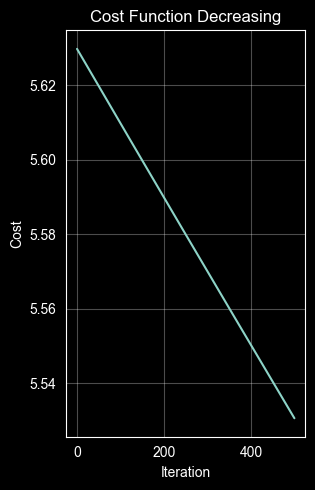

In [48]:
# Plot 4: Cost history
plt.figure(figsize=(12, 5))
plt.subplot(1, 4, 4)
plt.plot(model_multi.cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function Decreasing")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
# Calculate Cost
print(f"First cost: {model_multi.cost_history[0]:.4f}")
print(f"Last cost: {model_multi.cost_history[-1]:.4f}")
print(f"Improvement: {model_multi.cost_history[0] / model_poly.cost_history[-1]:.0f}x better!")

First cost: 5.6297
Last cost: 5.5307
Improvement: 8x better!


In [55]:

print("\n📊 FEATURE IMPORTANCE (weights):")
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude']

weights = model_multi.weights.flatten()
for feature, weight in sorted(zip(features, weights), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feature:12s}: {weight:8.4f}")




📊 FEATURE IMPORTANCE (weights):
  MedInc      :   0.8290
  Latitude    :  -0.4872
  Longitude   :  -0.4516
  HouseAge    :   0.1785
  AveBedrms   :   0.1568
  AveRooms    :  -0.1380
  AveOccup    :  -0.0452
  Population  :   0.0168


## 💡 INTERPRETATION:
 - Positive weight → Higher value increases price
 - Negative weight → Higher value decreases price